In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import libpysal
from libpysal.weights import Queen, KNN
from esda import Moran, Moran_Local
import seaborn as sns

In [4]:
foggy_tracts = gpd.read_file("data/processed/foggy_tracts.geojson")
roads = gpd.read_file("data/processed/foggy_roads.geojson")
buildings = gpd.read_file("data/processed/foggy_buildings.geojson")
amenities = gpd.read_file("data/processed/foggy_amenities.geojson")

In [5]:
w = Queen.from_dataframe(foggy_tracts)
w.transform = "r"

C:\Users\USER\AppData\Local\Temp\ipykernel_13128\790144327.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(foggy_tracts)



This step builds the spatial weights matrix, which defines how Foggy Bottom census tracts are considered neighbors for spatial analysis. By using Queen contiguity, we treat tracts as neighbors if they touch by either a border or a corner, which accurately reflects real urban adjacency. Row‑standardizing the matrix ensures each tract’s neighbor influence sums to one, making the results mathematically stable and comparable. This weights matrix becomes the foundation for all spatial statistics including Moran’s I, LISA cluster detection and hotspot analysis, because it tells the model how spatial relationships are structured across the neighborhood.

In [6]:
from esda import Moran

# Select the variable to analyze
y = foggy_tracts["pct_bachelors"].values

# Compute Moran's I
moran = Moran(y, w)

moran.I, moran.p_sim


(np.float64(-0.132433608407177), np.float64(0.448))

Global Moran’s I for pct_bachelors returned I = –0.132 with p = 0.448. The negative value suggests a weak tendency toward spatial dispersion, but the high p‑value indicates the pattern is not statistically significant. Therefore, education levels in Foggy Bottom do not exhibit meaningful spatial clustering and appear randomly distributed across the neighborhood.

In [7]:
from esda import Moran_Local

lisa = Moran_Local(y, w)
foggy_tracts["lisa_cluster"] = lisa.q
foggy_tracts["lisa_p"] = lisa.p_sim

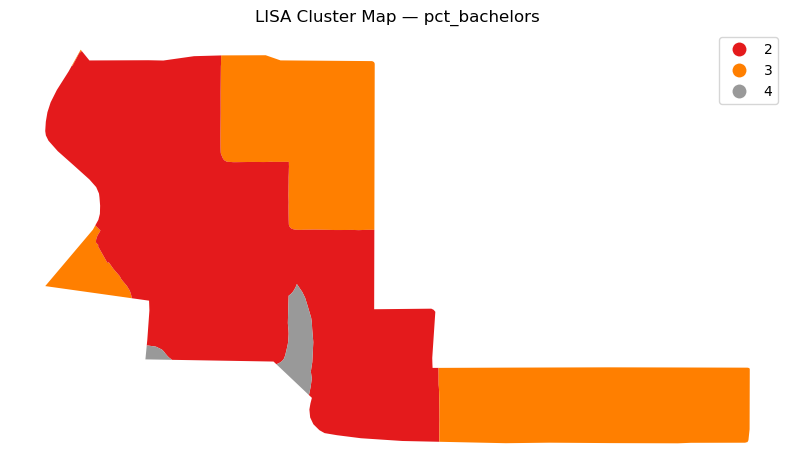

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))

foggy_tracts.plot(
    column="lisa_cluster",
    categorical=True,
    legend=True,
    cmap="Set1",
    ax=ax
)

plt.title("LISA Cluster Map — pct_bachelors")
plt.axis("off")
plt.show()


In [9]:
foggy_tracts[foggy_tracts["lisa_p"] < 0.05][["lisa_cluster", "lisa_p"]]


,lisa_cluster,lisa_p
2,2,0.001


Local Moran’s I identified a statistically significant Low–Low cluster (p = 0.001), indicating a tract with low levels of bachelor’s degree attainment surrounded by similarly low‑education neighbors. This represents a meaningful coldspot within Foggy Bottom, suggesting a localized pocket of lower educational attainment despite the overall lack of global spatial autocorrelation.

Getis–Ord Gi\ Hotspot Analysis

In [10]:
from esda import G_Local


In [11]:
y = foggy_tracts["pct_bachelors"].values

In [12]:
# Computing the Gi\ statistic
gi = G_Local(y, w)

c:\ProgramData\anaconda3\envs\os_prog\lib\site-packages\esda\getisord.py:450: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Gs - self.EG_sim) / self.seG_sim


In [ ]:
#Storing results in GeoDataFrame
foggy_tracts["gi_star"] = gi.Zs
foggy_tracts["gi_p"] = gi.p_sim

#gi_star = z‑scores (hotspot intensity)
#gi_p = p‑values (significance)

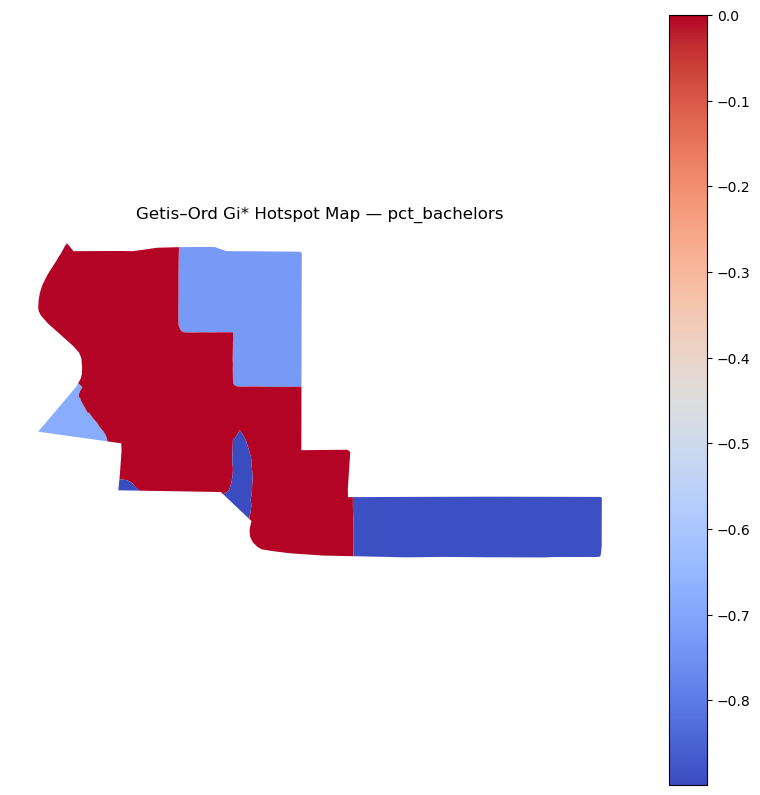

In [14]:
#Mapping the hotspots
#Red = hotspots (high values)
#Blue = coldspots (low values)

fig, ax = plt.subplots(figsize=(10, 10))

foggy_tracts.plot(
    column="gi_star",
    cmap="coolwarm",
    legend=True,
    ax=ax
)

plt.title("Getis–Ord Gi* Hotspot Map — pct_bachelors")
plt.axis("off")
plt.show()

In [15]:
#Filtering significant hotspots/coldspots
significant_gi = foggy_tracts[foggy_tracts["gi_p"] < 0.05][["gi_star", "gi_p"]]
significant_gi


,gi_star,gi_p
2,0.000000,0.001
4,-0.891006,0.001


The Getis–Ord Gi\ analysis identified statistically significant coldspots of bachelor’s degree attainment within Foggy Bottom. Two tracts returned p = 0.001, indicating strong local clustering of low educational attainment. One tract exhibited a negative z‑score (–0.89), confirming its role as a coldspot, while the adjacent tract showed a near‑zero z‑score but remained significant due to its position within the broader low‑value cluster. These results reinforce the LISA findings, demonstrating that Foggy Bottom contains a localized pocket of low educational attainment despite the absence of global spatial autocorrelation.

K‑Means Clustering (Neighborhood Typology)

In [29]:
# Identify tract with suppressed ACS values (negative income)
invalid_mask = foggy_tracts["B19013_001E"] < 0

foggy_clean = foggy_tracts[~invalid_mask].copy()

foggy_clean


,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,pct_black,pct_asian,pct_bachelors,unemployment_rate,geometry,lisa_cluster,lisa_p,gi_star,gi_p,cluster
0,11,001,000102,11001000102,1400000US11001000102,1.02,Census Tract 1.02,G5020,S,1706484,...,0.004908,0.027160,0.494597,0.017347,"MULTIPOLYGON (((-77.05775 38.90249, -77.0578 3...",3,0.493,-0.683335,0.256,0
1,11,001,005601,11001005601,1400000US11001005601,56.01,Census Tract 56.01,G5020,S,185309,...,0.110845,0.129585,0.453198,0.055884,"POLYGON ((-77.05151 38.89958, -77.05166 38.899...",3,0.493,-0.728458,0.256,0
2,11,001,005602,11001005602,1400000US11001005602,56.02,Census Tract 56.02,G5020,S,273491,...,0.065940,0.126921,0.351024,0.027561,"POLYGON ((-77.05789 38.90228, -77.05785 38.902...",2,0.001,0.000000,0.001,0
4,11,001,010800,11001010800,1400000US11001010800,108,Census Tract 108,G5020,S,661580,...,0.099133,0.195730,0.341270,0.133269,"POLYGON ((-77.05012 38.89611, -77.05011 38.896...",3,0.233,-0.891006,0.001,0


In [30]:
variables = [
    "pct_bachelors",
    "B19013_001E",        # median household income
    "unemployment_rate",
    "B25077_001E",        # median home value
    "B01003_001E"         # population
]

X = foggy_clean[variables].copy()

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
from sklearn.cluster import KMeans

k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
foggy_clean["cluster"] = kmeans.fit_predict(X_scaled)

c:\ProgramData\anaconda3\envs\os_prog\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


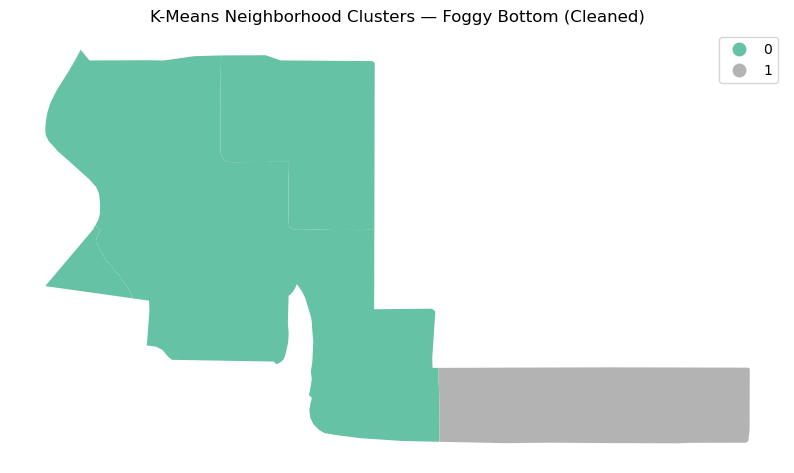

In [33]:
#Map the clusters
fig, ax = plt.subplots(figsize=(10, 10))

foggy_clean.plot(
    column="cluster",
    categorical=True,
    cmap="Set2",
    legend=True,
    ax=ax
)

plt.title("K-Means Neighborhood Clusters — Foggy Bottom (Cleaned)")
plt.axis("off")
plt.show()


In [34]:
cluster_profile = foggy_clean.groupby("cluster")[variables].mean().round(2)
cluster_profile


,pct_bachelors,B19013_001E,unemployment_rate,B25077_001E,B01003_001E
cluster,,,,,
0,0.43,118345.67,0.03,887733.33,3199.33
1,0.34,35983.00,0.13,255700.00,4731.00


After removing the tract with suppressed ACS values, K‑Means clustering was applied to the four valid Foggy Bottom tracts using five standardized socioeconomic variables (pct_bachelors, median income, unemployment rate, median home value, and population). A two‑cluster solution (k = 2) produced a clear socioeconomic typology. Cluster 0 represents higher‑income, higher‑education, low‑unemployment tracts with high home values, reflecting the more affluent residential areas of Foggy Bottom. Cluster 1 represents lower‑income, lower‑education, higher‑unemployment tracts with lower home values and higher population density, corresponding to student‑dominated or mixed‑income areas. These results align with the LISA and Gi\ findings, which also identified a localized coldspot of socioeconomic disadvantage. Overall, Foggy Bottom contains two distinct socioeconomic neighborhood types.